In [ ]:
import cv2
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [ ]:
import matplotlib.pyplot as plt


def detect_and_show_face(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Không đọc được ảnh:", image_path)
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    if len(faces) == 0:
        print("Không phát hiện khuôn mặt")
        plt.imshow(img_rgb)
        plt.title("Original Image (No Face Detected)")
        plt.axis("off")
        return

    x, y, w, h = faces[0]
    face = gray[y:y+h, x:x+w]

    img_box = img_rgb.copy()
    cv2.rectangle(img_box, (x, y), (x+w, y+h), (255, 0, 0), 2)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img_box)
    plt.title("Detected Face")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(face, cmap="gray")
    plt.title("Cropped Face (Gray)")
    plt.axis("off")

    plt.show()

    return face

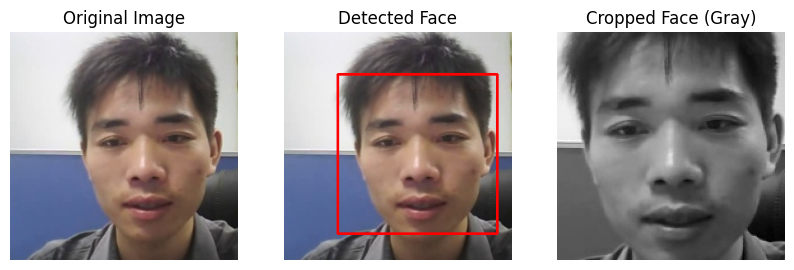

In [ ]:
image_real = "/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_25_real.jpg"  # đổi đường dẫn
face_gray = detect_and_show_face(image_real)

In [ ]:
from skimage.feature import local_binary_pattern

def extract_lbp(face_gray, show=True):

    face = cv2.resize(face_gray, (128, 128))

    P = 8    
    R = 1   
    METHOD = "uniform"

    lbp = local_binary_pattern(face, P, R, METHOD)

    n_bins = P + 2
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    if show:
        plt.figure(figsize=(4,4))
        plt.imshow(lbp, cmap="gray")
        plt.title("LBP (uniform)")
        plt.axis("off")
        plt.show()

    return hist


In [7]:
def extract_laplacian(face_gray, show=True):
    face = cv2.resize(face_gray, (128, 128))

    lap = cv2.Laplacian(face, cv2.CV_64F)
    lap_var = lap.var()

    if show:
        plt.figure(figsize=(4,4))
        plt.imshow(np.abs(lap), cmap="gray")
        plt.title(f"Laplacian (var={lap_var:.2f})")
        plt.axis("off")
        plt.show()

    return np.array([lap_var])


In [8]:
def extract_fft(face_gray, show=True):
    face = cv2.resize(face_gray, (128, 128))

    fft = np.fft.fft2(face)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log(np.abs(fft_shift) + 1)

    fft_mean = magnitude.mean()

    if show:
        plt.figure(figsize=(4,4))
        plt.imshow(magnitude, cmap="gray")
        plt.title("FFT Magnitude Spectrum")
        plt.axis("off")
        plt.show()

    return np.array([fft_mean])


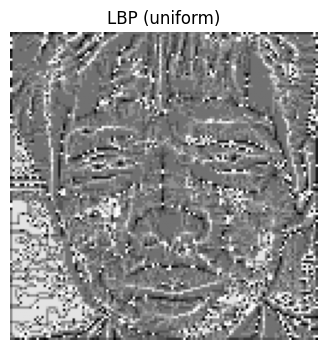

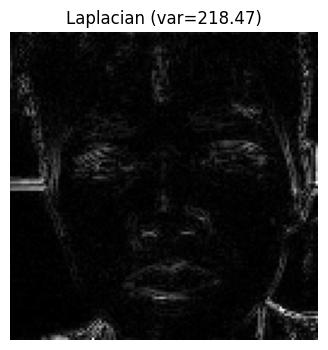

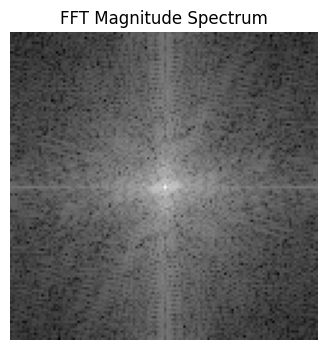

In [9]:
features = np.hstack([
    extract_lbp(face_gray, show=True),
    extract_laplacian(face_gray, show=True),
    extract_fft(face_gray, show=True)
])


In [ ]:
def extract_lbp_with_blur(face_gray, show=True):
    face = cv2.resize(face_gray, (128, 128))

    blurred = cv2.GaussianBlur(face, (5, 5), sigmaX=1.0)

    P = 8
    R = 1
    METHOD = "uniform"

    lbp = local_binary_pattern(blurred, P, R, METHOD)

    n_bins = P + 2
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    if show:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(face, cmap="gray")
        plt.title("Face (Gray)")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(blurred, cmap="gray")
        plt.title("Gaussian Blurred")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(lbp, cmap="gray")
        plt.title("LBP after Blur")
        plt.axis("off")

        plt.show()

    return hist


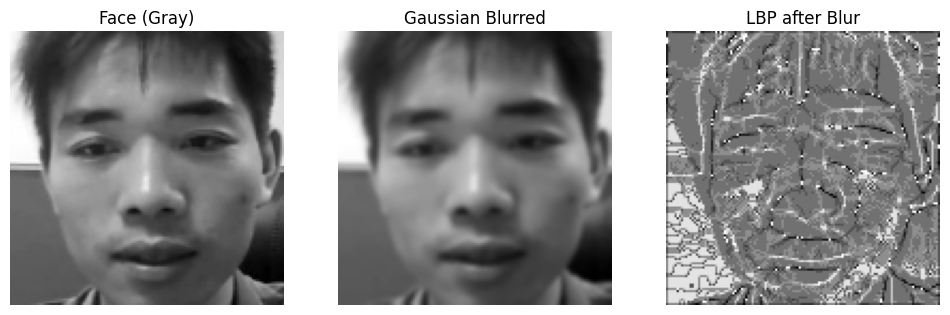

In [11]:
lbp_blur = extract_lbp_with_blur(face_gray, show=True)

In [12]:
def extract_laplacian_advanced(face_gray, show=True):
    face = cv2.resize(face_gray, (128,128))

    lap = cv2.Laplacian(face, cv2.CV_64F)
    abs_lap = np.abs(lap)

    mean = abs_lap.mean()
    std  = abs_lap.std()
    var  = abs_lap.var()

    if show:
        plt.figure(figsize=(4,4))
        plt.imshow(abs_lap, cmap="gray")
        plt.title("Laplacian Magnitude")
        plt.axis("off")
        plt.show()

    return np.array([mean, std, var])


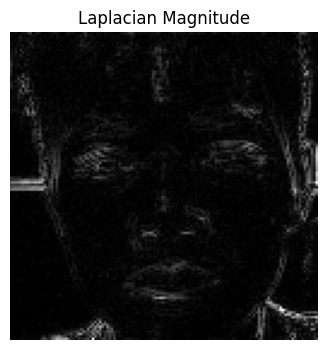

array([  7.46514893,  12.75712141, 162.74414673])

In [16]:
extract_laplacian_advanced(face_gray, show=True)

In [13]:
def extract_laplacian_block(face_gray, block=4):
    face = cv2.resize(face_gray, (128,128))
    lap = np.abs(cv2.Laplacian(face, cv2.CV_64F))

    h, w = face.shape
    bh, bw = h//block, w//block

    features = []
    for i in range(block):
        for j in range(block):
            region = lap[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
            features.append(region.var())

    return np.array(features)


In [17]:
extract_laplacian_block(face_gray, block=4)

array([ 67.88957882,  48.22273922,  20.71082973, 100.92824936,
       287.22650146, 108.50897121,  49.26656723, 437.40310574,
       176.99796963,  39.65624142,  40.77124023, 170.17076015,
       129.31402206, 237.04033566,  60.62270737, 452.20848083])

In [14]:
def extract_fft_radial(face_gray, bins=10, show=True):
    face = cv2.resize(face_gray, (128,128))

    fft = np.fft.fft2(face)
    fft_shift = np.fft.fftshift(fft)
    mag = np.abs(fft_shift)

    h, w = mag.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)
    dist = dist / dist.max()

    features = []
    for i in range(bins):
        mask = (dist >= i/bins) & (dist < (i+1)/bins)
        features.append(mag[mask].mean())

    if show:
        plt.imshow(np.log(mag+1), cmap="gray")
        plt.title("FFT Magnitude")
        plt.axis("off")
        plt.show()

    return np.array(features)


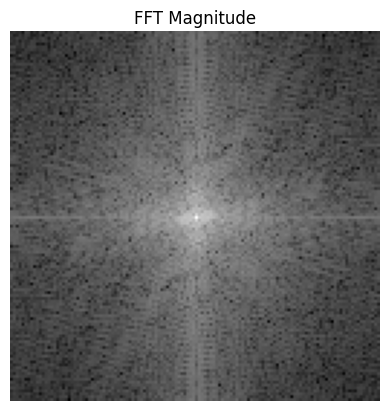

array([35475.71208066,  5534.42010303,  2251.99442231,  1147.05194524,
         705.73920134,   461.53002306,   326.96136069,   169.10081125,
         106.35914328,    81.58057413])

In [18]:
extract_fft_radial(face_gray, bins=10, show=True)

In [15]:
def extract_fft_band_ratio(face_gray):
    face = cv2.resize(face_gray, (128,128))

    fft = np.fft.fft2(face)
    mag = np.abs(np.fft.fftshift(fft))

    h, w = mag.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)

    low  = mag[dist < 20].mean()
    high = mag[dist > 40].mean()

    return np.array([low, high, high/(low+1e-6)])


In [19]:
extract_fft_band_ratio(face_gray)


array([1.12001222e+04, 3.39350504e+02, 3.02988216e-02])

Total contours: 29
Filtered contours: 25


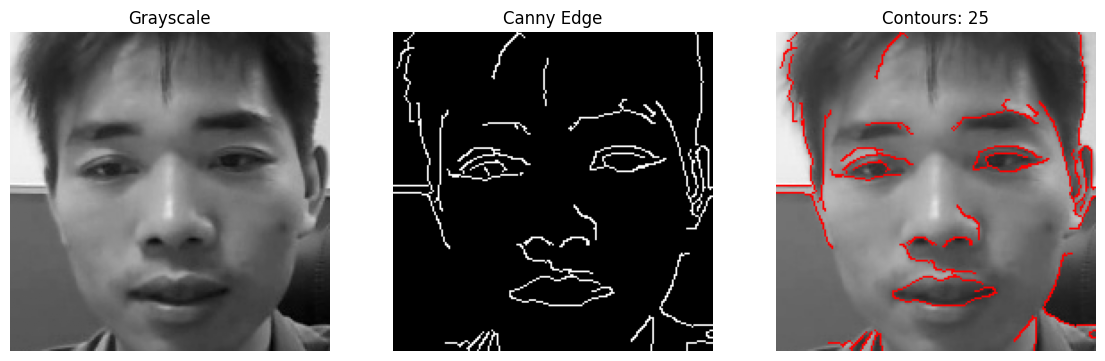

In [ ]:
blurred = cv2.GaussianBlur(face_gray, (5, 5), 0)
edged = cv2.Canny(blurred, 50, 150)

contours, _ = cv2.findContours(
    edged.copy(),
    cv2.RETR_LIST,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours:", len(contours))

img_contours = cv2.cvtColor(face_gray, cv2.COLOR_GRAY2RGB)

MIN_AREA = 1
filtered_contours = [
    c for c in contours if cv2.contourArea(c) > MIN_AREA
]

print("Filtered contours:", len(filtered_contours))

# Vẽ contour (đỏ)
cv2.drawContours(
    img_contours,
    filtered_contours,
    -1,
    (255, 0, 0),
    1
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(face_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edged, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_contours)
plt.title(f"Contours: {len(filtered_contours)}")
plt.axis("off")

plt.show()


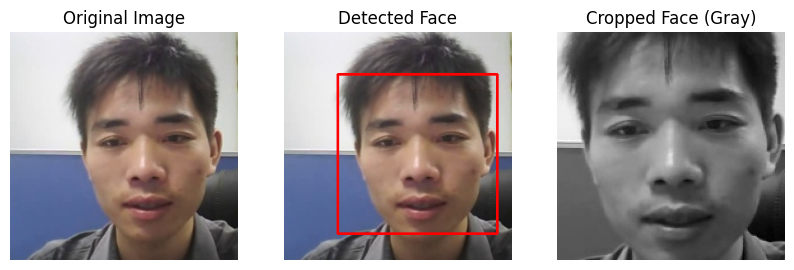

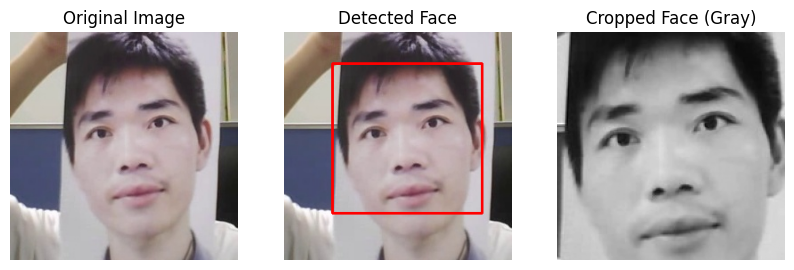

In [33]:
image_fake = "/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_3.avi_25_fake.jpg"
image_real = "/Users/tinld/Documents/Code/python-dev/face-anti-spoofing/data/test_img/test_img/color/1_1.avi_25_real.jpg"  # đổi đường dẫn
face_gray = detect_and_show_face(image_real)
face_gray_fake = detect_and_show_face(image_fake)


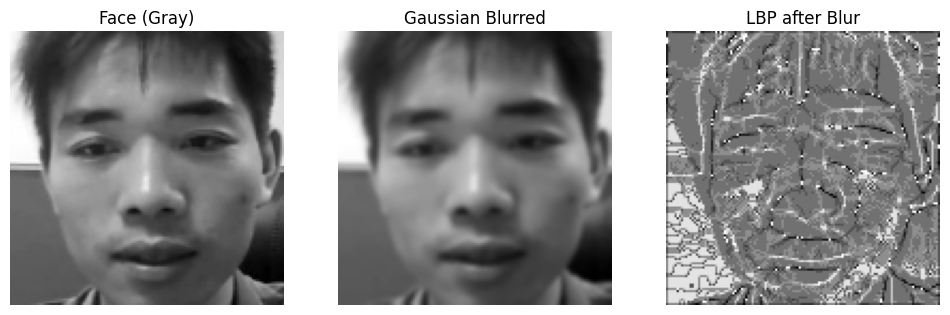

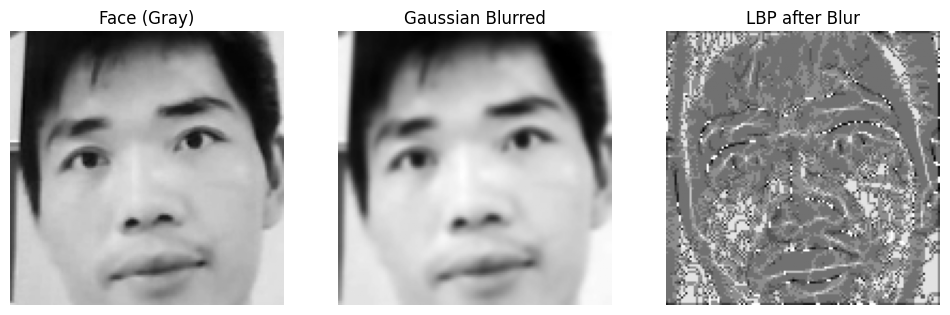

LBP REAL hist (first 5): [0.0022583  0.01477051 0.01635742 0.10186768 0.47076416]
LBP FAKE hist (first 5): [0.00158691 0.01159668 0.00933838 0.09265137 0.45147705]


In [34]:
lbp_real = extract_lbp_with_blur(face_gray, show=True)
lbp_fake = extract_lbp_with_blur(face_gray_fake, show=True)

print("LBP REAL hist (first 5):", lbp_real[:5])
print("LBP FAKE hist (first 5):", lbp_fake[:5])

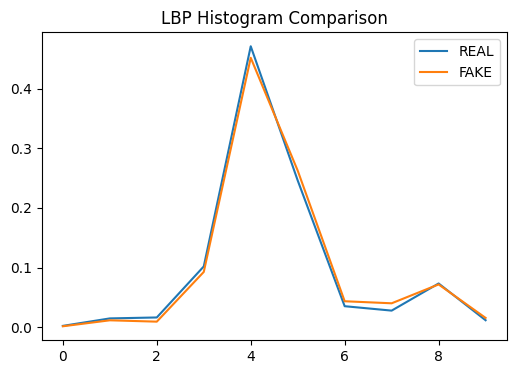

In [36]:
plt.figure(figsize=(6,4))
plt.plot(lbp_real, label="REAL")
plt.plot(lbp_fake, label="FAKE")
plt.title("LBP Histogram Comparison")
plt.legend()
plt.show()

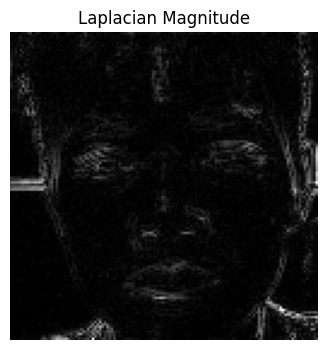

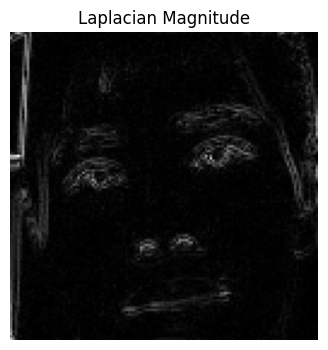

Laplacian REAL [mean, std, var]: [  7.46514893  12.75712141 162.74414673]
Laplacian FAKE [mean, std, var]: [  6.49963379  11.46855841 131.5278319 ]


In [37]:
lap_real = extract_laplacian_advanced(face_gray, show=True)
lap_fake = extract_laplacian_advanced(face_gray_fake, show=True)

print("Laplacian REAL [mean, std, var]:", lap_real)
print("Laplacian FAKE [mean, std, var]:", lap_fake)


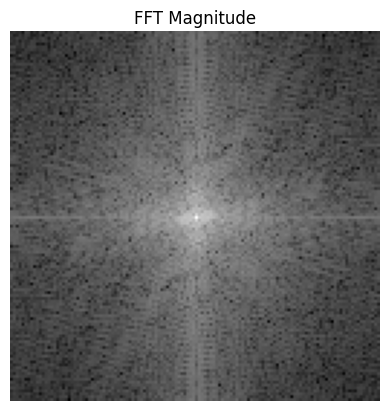

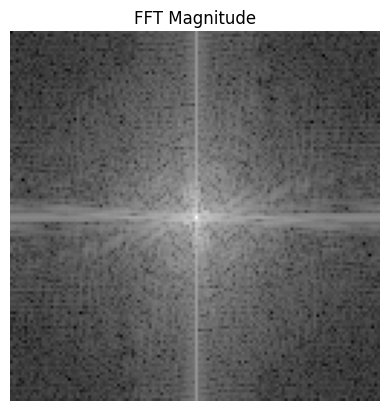

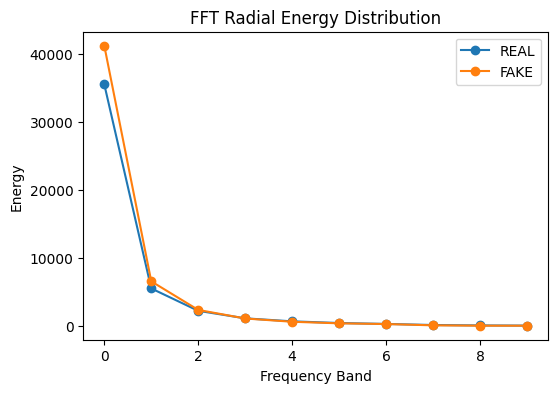

In [38]:
fft_real = extract_fft_radial(face_gray, show=True)
fft_fake = extract_fft_radial(face_gray_fake, show=True)

plt.figure(figsize=(6,4))
plt.plot(fft_real, marker="o", label="REAL")
plt.plot(fft_fake, marker="o", label="FAKE")
plt.title("FFT Radial Energy Distribution")
plt.xlabel("Frequency Band")
plt.ylabel("Energy")
plt.legend()
plt.show()


In [ ]:
def extract_laplacian_visual(face_gray, show=True):
    face = cv2.resize(face_gray, (128,128))

    blurred = cv2.GaussianBlur(face, (3,3), 0)

    edges = cv2.Canny(face, 50, 150)
    lap = cv2.Laplacian(face, cv2.CV_64F)
    abs_lap = np.abs(lap)

    masked_lap_vec = abs_lap[edges > 0]

    mean = masked_lap_vec.mean()
    std  = masked_lap_vec.std()
    var  = masked_lap_vec.var()

    masked_lap_img = np.zeros_like(abs_lap)
    masked_lap_img[edges > 0] = abs_lap[edges > 0]

    if show:
        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(face, cmap="gray")
        plt.title("Face Gray")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(blurred, cmap="gray")
        plt.title("Blurred")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(edges, cmap="gray")
        plt.title("Canny Edges")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(masked_lap_img, cmap="hot")
        plt.title("Masked Laplacian")
        plt.axis("off")

        plt.show()

    return np.array([mean, std, var])


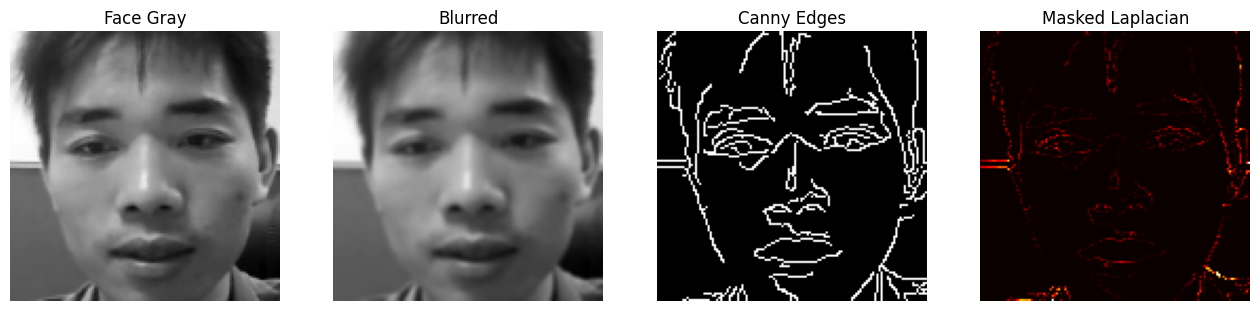

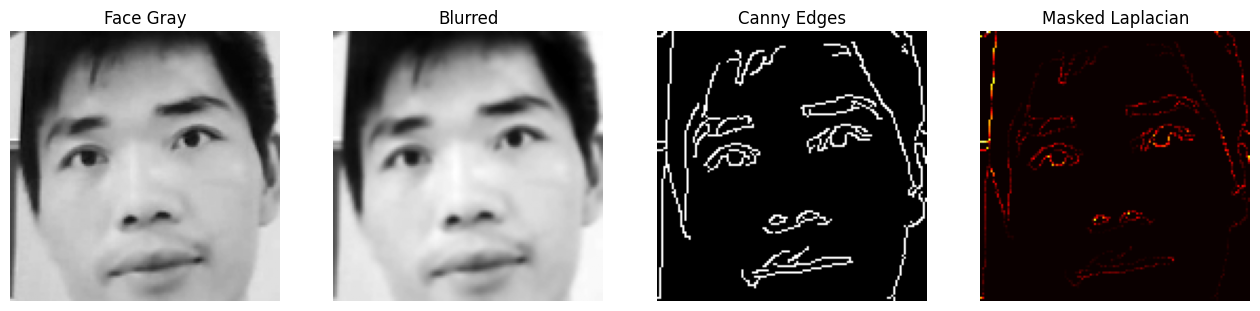

Laplacian REAL [mean, std, var]: [ 14.85093168  19.86338783 394.55417615]
Laplacian FAKE [mean, std, var]: [ 13.61181102  15.76774398 248.62175026]


In [46]:
lap_real = extract_laplacian_visual(face_gray, show=True)
lap_fake = extract_laplacian_visual(face_gray_fake, show=True)

print("Laplacian REAL [mean, std, var]:", lap_real)
print("Laplacian FAKE [mean, std, var]:", lap_fake)


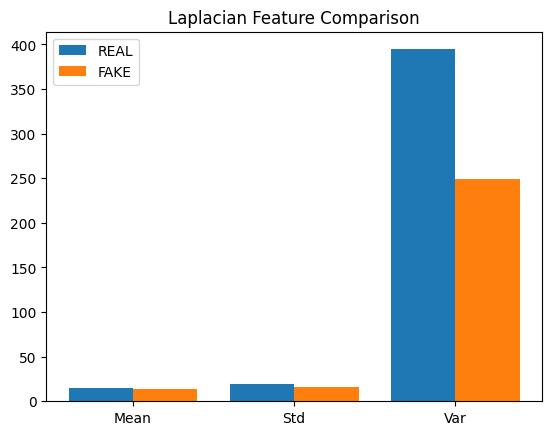

In [47]:
labels = ["Mean", "Std", "Var"]

x = np.arange(len(labels))
plt.bar(x - 0.2, lap_real, 0.4, label="REAL")
plt.bar(x + 0.2, lap_fake, 0.4, label="FAKE")

plt.xticks(x, labels)
plt.title("Laplacian Feature Comparison")
plt.legend()
plt.show()


In [ ]:
def extract_laplacian_visual_sobel(face_gray, show=True):
    face = cv2.resize(face_gray, (128,128))

    blurred = cv2.GaussianBlur(face, (3,3), 0)

    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = sobel_mag / (sobel_mag.max() + 1e-6)

    edges = (sobel_mag > 0.2).astype(np.uint8)

    lap = cv2.Laplacian(blurred, cv2.CV_64F)
    abs_lap = np.abs(lap)

    masked_lap_vec = abs_lap[edges > 0]

    mean = masked_lap_vec.mean() if masked_lap_vec.size > 0 else 0
    std  = masked_lap_vec.std()  if masked_lap_vec.size > 0 else 0
    var  = masked_lap_vec.var()  if masked_lap_vec.size > 0 else 0

    masked_lap_img = np.zeros_like(abs_lap)
    masked_lap_img[edges > 0] = abs_lap[edges > 0]

    if show:
        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(face, cmap="gray")
        plt.title("Face Gray")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(blurred, cmap="gray")
        plt.title("Blurred")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(edges, cmap="gray")
        plt.title("Sobel Edges")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(masked_lap_img, cmap="hot")
        plt.title("Masked Laplacian (Sobel)")
        plt.axis("off")

        plt.show()

    return np.array([mean, std, var])


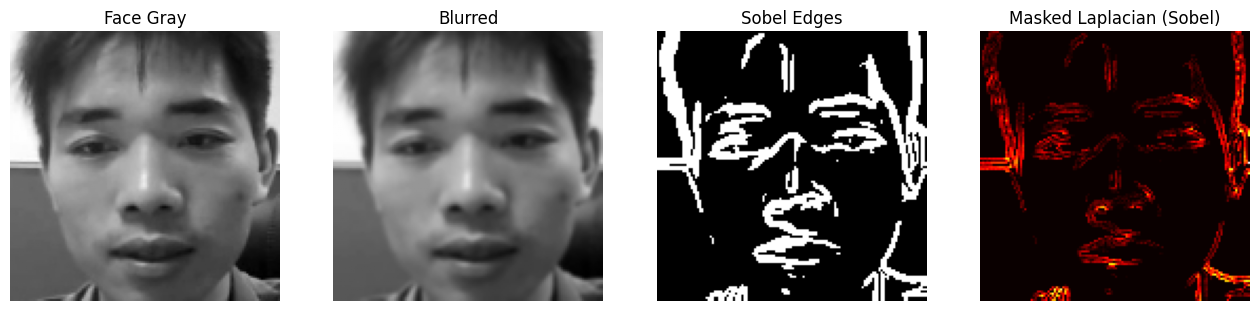

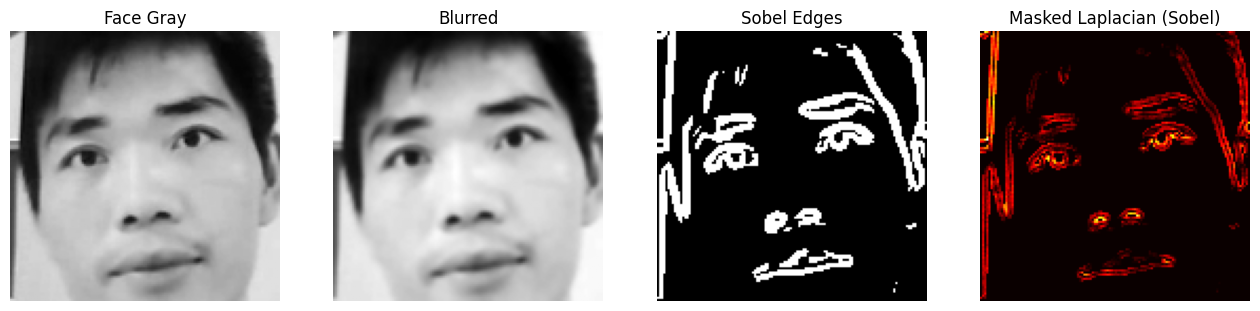

Laplacian REAL [mean, std, var]: [ 9.60382916  8.71171659 75.89400596]
Laplacian FAKE [mean, std, var]: [12.06232194  9.25336032 85.62467723]


In [53]:
lap_real = extract_laplacian_visual_sobel(face_gray, show=True)
lap_fake = extract_laplacian_visual_sobel(face_gray_fake, show=True)

print("Laplacian REAL [mean, std, var]:", lap_real)
print("Laplacian FAKE [mean, std, var]:", lap_fake)

In [ ]:
def fft_low_high_decode(face_gray, radius=15, show=True):
    face = cv2.resize(face_gray, (128,128))

    fft = np.fft.fft2(face)
    fft_shift = np.fft.fftshift(fft)

    h, w = face.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)

    low_mask = dist <= radius
    high_mask = dist > radius

    low_fft  = fft_shift * low_mask
    high_fft = fft_shift * high_mask

    low_img  = np.abs(np.fft.ifft2(np.fft.ifftshift(low_fft)))
    high_img = np.abs(np.fft.ifft2(np.fft.ifftshift(high_fft)))

    if show:
        plt.figure(figsize=(18,4))

        plt.subplot(1,5,1)
        plt.imshow(face, cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,5,2)
        plt.imshow(np.log(np.abs(fft_shift)+1), cmap="gray")
        plt.title("FFT Magnitude")
        plt.axis("off")

        plt.subplot(1,5,3)
        plt.imshow(low_img, cmap="gray")
        plt.title("Low Frequency Decode")
        plt.axis("off")

        plt.subplot(1,5,4)
        plt.imshow(high_img, cmap="gray")
        plt.title("High Frequency Decode")
        plt.axis("off")

        plt.subplot(1,5,5)
        plt.imshow(high_mask, cmap="gray")
        plt.title("High-Freq Mask")
        plt.axis("off")

        plt.show()

    return low_img, high_img


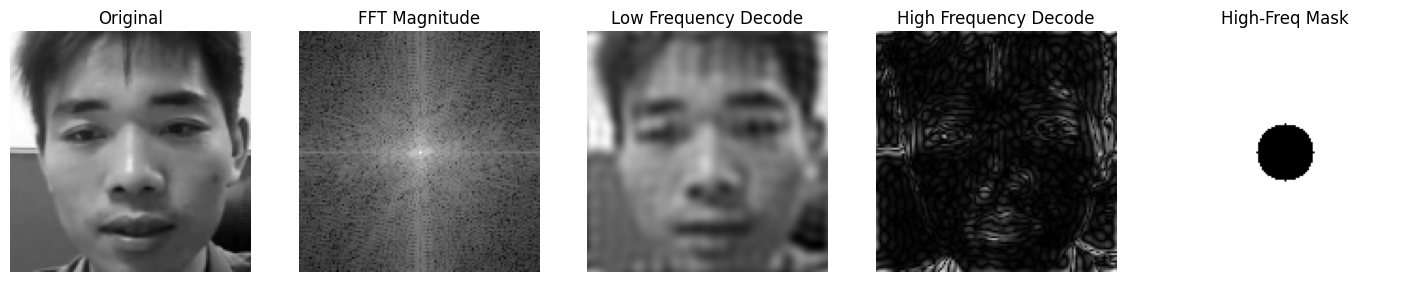

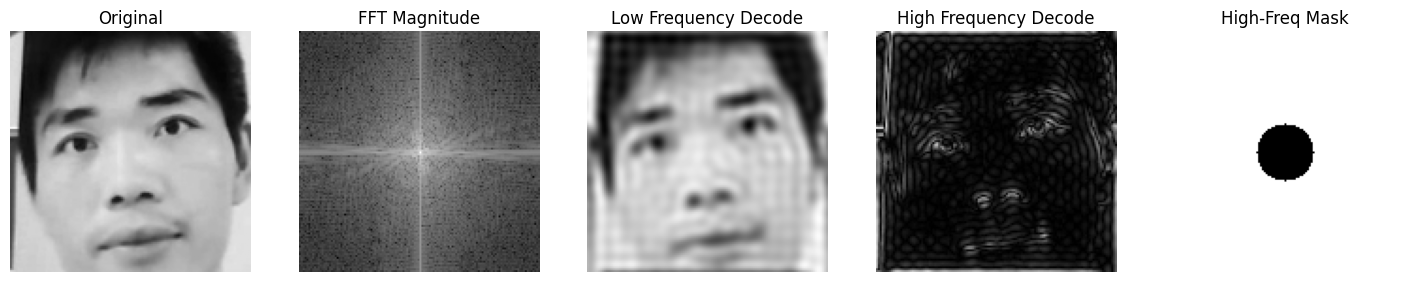

In [49]:
low_img_real, high_img_real = fft_low_high_decode(face_gray, radius=15, show=True)
low_img_fake, high_img_fake = fft_low_high_decode(face_gray_fake, radius=15, show=True)

In [ ]:
def extract_fft_numeric(face_gray, radius=15, show=True):
    face = cv2.resize(face_gray, (128,128))

    fft = np.fft.fft2(face)
    fft_shift = np.fft.fftshift(fft)
    mag = np.abs(fft_shift)

    h, w = mag.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)

    low_mask  = dist <= radius
    high_mask = dist > radius

    total_energy = mag.mean()
    low_energy   = mag[low_mask].mean()
    high_energy  = mag[high_mask].mean()

    hf_lf_ratio = high_energy / (low_energy + 1e-6)

    mag_norm = mag / (mag.sum() + 1e-6)
    spectral_entropy = -np.sum(mag_norm * np.log(mag_norm + 1e-12))

    low_img  = np.abs(np.fft.ifft2(np.fft.ifftshift(fft_shift * low_mask)))
    high_img = np.abs(np.fft.ifft2(np.fft.ifftshift(fft_shift * high_mask)))

    if show:
        print("FFT STATISTICS")
        print("-------------------------")
        print(f"Total energy     : {total_energy:.4f}")
        print(f"Low-freq energy  : {low_energy:.4f}")
        print(f"High-freq energy : {high_energy:.4f}")
        print(f"HF / LF ratio    : {hf_lf_ratio:.4f}")
        print(f"Spectral entropy : {spectral_entropy:.4f}")

        plt.figure(figsize=(18,4))

        plt.subplot(1,4,1)
        plt.imshow(face, cmap="gray")
        plt.title("Face")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(np.log(mag+1), cmap="gray")
        plt.title("FFT Magnitude")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(low_img, cmap="gray")
        plt.title("Low-Freq Decode")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(high_img, cmap="gray")
        plt.title("High-Freq Decode")
        plt.axis("off")

        plt.show()

    return np.array([
        total_energy,
        low_energy,
        high_energy,
        hf_lf_ratio,
        spectral_entropy
    ])


FFT STATISTICS
-------------------------
Total energy     : 1392.8869
Low-freq energy  : 16972.6527
High-freq energy : 688.1944
HF / LF ratio    : 0.0405
Spectral entropy : 7.8487


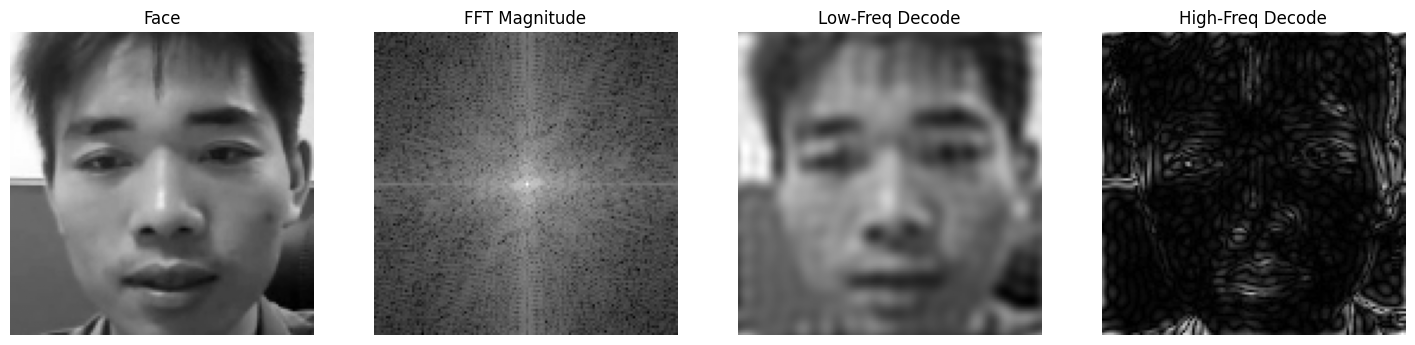

FFT STATISTICS
-------------------------
Total energy     : 1508.0324
Low-freq energy  : 19803.9809
High-freq energy : 680.4836
HF / LF ratio    : 0.0344
Spectral entropy : 7.4921


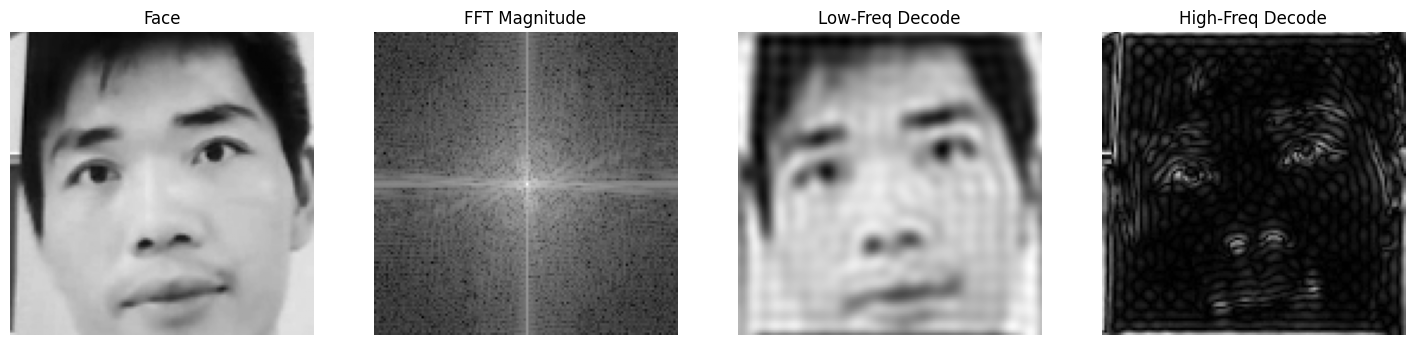

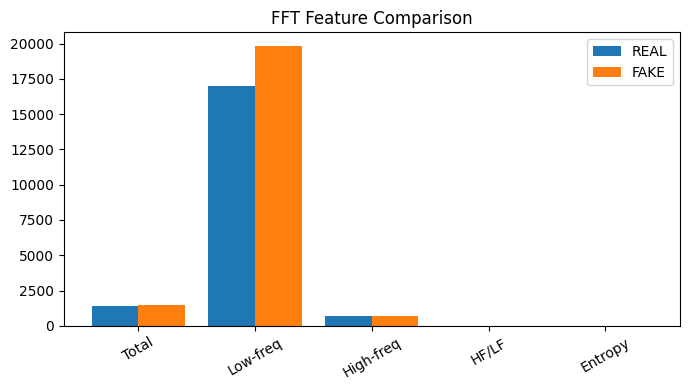

In [51]:
fft_real = extract_fft_numeric(face_gray, show=True)
fft_fake = extract_fft_numeric(face_gray_fake, show=True)

labels = [
    "Total",
    "Low-freq",
    "High-freq",
    "HF/LF",
    "Entropy"
]

plt.figure(figsize=(7,4))
plt.bar(np.arange(len(labels))-0.2, fft_real, 0.4, label="REAL")
plt.bar(np.arange(len(labels))+0.2, fft_fake, 0.4, label="FAKE")
plt.xticks(np.arange(len(labels)), labels, rotation=30)
plt.title("FFT Feature Comparison")
plt.legend()
plt.tight_layout()
plt.show()
